# InsurPrime: Can You Guess the Insurance Premium?
by Crédit Agricole Assurances

## Feature Engineering & Baseline Model

In [11]:
from data_preprocessing import preprocess_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import PoissonRegressor, TweedieRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
import os

### Loading Data & preprocessing

In [3]:
X_train=pd.read_csv("Data/x-train.csv")
y_train=pd.read_csv("Data/y-train.csv")
X_test=pd.read_csv("Data/x-test.csv")

/tmp/ipykernel_1507990/1278827676.py:1: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train=pd.read_csv("Data/x-train.csv")
/tmp/ipykernel_1507990/1278827676.py:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test=pd.read_csv("Data/x-test.csv")


In [15]:
test_ids = X_test["ID"].copy()
test_exposure = X_test["ANNEE_ASSURANCE"]

In [5]:
X_train_clean, y_train_clean, fitted = preprocess_data(
    X_train, 
    y_train, 
    is_train=True
)

In [6]:
# test
X_test_clean, _, _ = preprocess_data(
    X_test, 
    is_train=False,
    fitted_transformers=fitted
)

### Feature engineering

In [7]:
def add_engineered_features(X_df, is_train=True, feature_meta=None,
                            rare_threshold=200):
    """   
    - Aggregate SURFACE*, KAPITAL*, NBBAT*
    - Prevention, weather, risk, and grouping features.
    - Derived features (log exposure, complexity).
    - Uses feature_meta only for rare-category grouping so train/test mappings match.
    """
    if feature_meta is None:
        feature_meta = {}

    X = X_df.copy()

    # exposure
    if "ANNEE_ASSURANCE" in X.columns:
        # log exposure
        X["LOG_EXPOSURE"] = np.log1p(X["ANNEE_ASSURANCE"].astype(float))


    # SURFACE aggregates
    surface_cols = [c for c in X.columns if c.startswith("SURFACE")]
    if surface_cols:
        # Cast to numeric for arithmetic; categories/strings -> numbers
        surface_num = X[surface_cols].apply(pd.to_numeric, errors="coerce")

        X["TOT_SURFACE"] = surface_num.fillna(0).sum(axis=1)
        X["SURFACE_NONZERO_COUNT"] = (surface_num.fillna(0) > 0).sum(axis=1)
        X["SURFACE_MAX"] = surface_num.fillna(0).max(axis=1)

    # NBBAT aggregates
    nbbat_cols = [c for c in X.columns if c.startswith("NBBAT")]
    if nbbat_cols:
        nbbat_num = X[nbbat_cols].apply(pd.to_numeric, errors="coerce")

        X["TOT_BUILDINGS"] = nbbat_num.fillna(0).sum(axis=1)
        if "TOT_SURFACE" in X.columns:
            X["AVG_SURFACE_PER_BUILDING"] = (
                X["TOT_SURFACE"] / (1.0 + X["TOT_BUILDINGS"])
            )


    # Simple complexity proxy: more buildings + more surface types = more complex farm
    if ("TOT_BUILDINGS" in X.columns) and ("SURFACE_NONZERO_COUNT" in X.columns):
        X["COMPLEXITY_INDEX"] = X["TOT_BUILDINGS"] + X["SURFACE_NONZERO_COUNT"]

    # KAPITAL aggregates
    kap_cols = [c for c in X.columns if c.startswith("KAPITAL")]
    if kap_cols:
        kap_num = X[kap_cols].apply(pd.to_numeric, errors="coerce")
        X["TOT_KAPITAL"] = kap_num.fillna(0).sum(axis=1)
        X["KAPITAL_NONZERO_COUNT"] = (kap_num.fillna(0) > 0).sum(axis=1)
        X["LOG_TOT_KAPITAL"] = np.log1p(X["TOT_KAPITAL"])


    # Prevention features (PREV*)
    prev_cols = [c for c in X.columns if c.upper().startswith("PREV")]
    if prev_cols:
        X["N_PREVENTION"] = X[prev_cols].notna().sum(axis=1)
        X["NO_PREVENTION_FLAG"] = (X["N_PREVENTION"] == 0).astype(int)

    # Weather features
    # DRY_INDEX = dry days / (1 + rain)
    if {"NBJDRY_MM_A", "RR_MM_A"}.issubset(X.columns):
        X["DRY_INDEX"] = X["NBJDRY_MM_A"] / (1.0 + X["RR_MM_A"].clip(lower=0))

    # Wind risk: high wind zone (ZONE_VENT == 3)
    if "ZONE_VENT" in X.columns:
        zone_vent_vals = pd.to_numeric(X["ZONE_VENT"], errors="coerce")
        X["VENT_HIGH"] = (zone_vent_vals == 3).astype(int)

    # Activity / Vocation grouping (rare categories)
    # ACTIVIT2
    if "ACTIVIT2" in X.columns:
        # Work as string to avoid categorical headaches
        activ = X["ACTIVIT2"].astype("string")

        if is_train:
            vc_act = activ.value_counts()
            rare_act = vc_act[vc_act < rare_threshold].index.astype(str)
            feature_meta["activit2_rare"] = list(rare_act)
        else:
            rare_act = feature_meta.get("activit2_rare", [])

        X["ACTIVIT2_GRP"] = activ.where(~activ.isin(rare_act), "OTHER").astype("category")

    # VOCATION
    if "VOCATION" in X.columns:
        voc = X["VOCATION"].astype("string")

        if is_train:
            vc_voc = voc.value_counts()
            rare_voc = vc_voc[vc_voc < rare_threshold].index.astype(str)
            feature_meta["vocation_rare"] = list(rare_voc)
        else:
            rare_voc = feature_meta.get("vocation_rare", [])

        X["VOCATION_GRP"] = voc.where(~voc.isin(rare_voc), "OTHER").astype("category")

        
    # Contract age / "new business"
    if "ANCIENNETE" in X.columns:
        X["IS_NEW_CONTRACT"] = (X["ANCIENNETE"].astype(float) < 1).astype(int)

    # Risk-related features (RISK*)
    risk_cols = [c for c in X.columns if c.startswith("RISK")]
    if risk_cols:
        X["RISK_ALERTS"] = X[risk_cols].notna().sum(axis=1)


    # Simple interactions

    # Surface x Prevention
    if ("TOT_SURFACE" in X.columns) and ("N_PREVENTION" in X.columns):
        X["SURFACE_PREVENTION"] = X["TOT_SURFACE"] * X["N_PREVENTION"]

    # Capital x Zone
    if ("LOG_TOT_KAPITAL" in X.columns) and ("ZONE" in X.columns):
        zone_codes = pd.to_numeric(X["ZONE"], errors="coerce")
        X["KAPITAL_ZONE"] = X["LOG_TOT_KAPITAL"] * (zone_codes.fillna(0))

    # Buildings x Dryness
    if ("TOT_BUILDINGS" in X.columns) and ("DRY_INDEX" in X.columns):
        X["BUILDINGS_DRY"] = X["TOT_BUILDINGS"] * X["DRY_INDEX"]

    return X, feature_meta

In [8]:
# train
X_train_fe, fe_meta = add_engineered_features(X_train_clean, is_train=True)

# test
X_test_fe, _ = add_engineered_features(X_test_clean, is_train=False, feature_meta=fe_meta)

In [9]:
# Confirm shapes
print("\nShapes after feature engineering:")
print(f"X_train_fe shape: {X_train_fe.shape}")
print(f"y_train_processed shape: {y_train_clean.shape}")
print(f"X_test_fe shape: {X_test_fe.shape}")


Shapes after feature engineering:
X_train_fe shape: (383610, 380)
y_train_processed shape: (383610, 5)
X_test_fe shape: (95852, 380)


### Baseline model

#### Benchmark Structure
The benchmark consists of two separate GLMs:

Claim Frequency:
- Distribution: Poisson
- Link Function: Log

Average Claim Cost:
- Distribution: Tweedie
- Link Function: Log


In [12]:
# Combine to ordinal-encode categorical columns consistently
n_train = len(X_train_fe)
X_comb = pd.concat([X_train_fe, X_test_fe], axis=0, ignore_index=True)
cat_cols = X_comb.select_dtypes(include=["object", "category"]).columns.tolist()

if len(cat_cols) > 0:
    ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_comb[cat_cols] = ord_enc.fit_transform(X_comb[cat_cols].astype(str))

X_train_enc = X_comb.iloc[:n_train].copy()
X_test_enc = X_comb.iloc[n_train:].copy()

# Targets and exposure
exposure = pd.to_numeric(X_train_enc["ANNEE_ASSURANCE"], errors="coerce").fillna(0).clip(lower=0)
test_exposure = pd.to_numeric(X_test_enc["ANNEE_ASSURANCE"], errors="coerce").fillna(0).clip(lower=0)

# Remove exposure from feature matrix to avoid leakage/double use
feature_cols = [c for c in X_train_enc.columns if c != "ANNEE_ASSURANCE"]
X_train_model = X_train_enc[feature_cols]
X_test_model = X_test_enc[feature_cols]

In [13]:
y_freq = y_train_clean["FREQ"].astype(float)
y_cm = y_train_clean["CM"].astype(float)
charge = y_train_clean["CHARGE"].astype(float)


# Train/validation split
(
    X_tr,
    X_val,
    y_freq_tr,
    y_freq_val,
    y_cm_tr,
    y_cm_val,
    charge_tr,
    charge_val,
    exposure_tr,
    exposure_val,
) = train_test_split(
    X_train_enc,
    y_freq,
    y_cm,
    charge,
    exposure,
    test_size=0.2,
    random_state=42,
)

# Frequency model val
print("Training Poisson frequency GLM on train split...")
freq_model_val = PoissonRegressor(alpha=1.0, max_iter=300)
freq_model_val.fit(X_tr.fillna(0).values, y_freq_tr.values)

pred_freq_val = np.clip(freq_model_val.predict(X_val.fillna(0).values), 0, None)


# Severity model val

print("Training Tweedie severity GLM on CM > 0 (train split)...")
mask_claims_tr = y_cm_tr > 0

if mask_claims_tr.sum() == 0:
    print(
        "No positive CM values in train split — using constant severity for validation."
    )
    pred_sev_val = np.full(len(X_val), fill_value=1.0)
else:
    X_sev_tr = X_tr[mask_claims_tr].fillna(0).values
    y_sev_tr = y_cm_tr[mask_claims_tr].clip(lower=1e-6).values

    sev_model_val = TweedieRegressor(power=1.5, alpha=0.1, max_iter=1000, link="log")
    sev_model_val.fit(X_sev_tr, y_sev_tr)

    pred_sev_val = np.clip(sev_model_val.predict(X_val.fillna(0).values), 0, None)


# Validation CHARGE & RMSE

pred_charge_val = pred_freq_val * pred_sev_val * exposure_val.to_numpy(dtype=float)

val_rmse = mean_squared_error(charge_val.values, pred_charge_val, squared=False)
print(f"Validation RMSE: {val_rmse:.6f}")

Training Poisson frequency GLM on train split...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


Training Tweedie severity GLM on CM > 0 (train split)...
Validation RMSE: 7043.090937


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# Retrain on full training set for final submission

# Frequency model: PoissonRegressor
print("Retraining Poisson frequency GLM on full training data...")
freq_model = PoissonRegressor(alpha=1.0, max_iter=300)
freq_model.fit(X_train_enc.fillna(0).values, y_freq.values)
pred_freq_test = np.clip(freq_model.predict(X_test_enc.fillna(0).values), 0, None)

# Severity model: TweedieRegressor on CM > 0
print("Retraining Tweedie severity GLM on CM > 0 (full training data)...")
mask_claims_full = y_cm > 0

if mask_claims_full.sum() == 0:
    print(
        "No positive CM values in full training set — using constant severity for test."
    )
    pred_sev_test = np.full(len(X_test_enc), fill_value=1.0)
else:
    X_sev_full = X_train_enc[mask_claims_full].fillna(0).values
    y_sev_full = y_cm[mask_claims_full].clip(lower=1e-6).values

    sev_model = TweedieRegressor(power=1.5, alpha=0.1, max_iter=1000, link="log")
    sev_model.fit(X_sev_full, y_sev_full)

    pred_sev_test = np.clip(sev_model.predict(X_test_enc.fillna(0).values), 0, None)

# Final charge = freq * sev * exposure (ANNEE_ASSURANCE)
test_exposure_clean = pd.to_numeric(test_exposure, errors="coerce").fillna(0).clip(lower=0)
pred_charge_test = pred_freq_test * pred_sev_test * test_exposure.to_numpy(dtype=float)
pred_charge_test = np.clip(pred_charge_test, 0, None)

submission = pd.DataFrame(
    {
        "ID": test_ids,
        "FREQ": pred_freq_test,
        "CM": pred_sev_test,
        "ANNEE_ASSURANCE": test_exposure,
        "CHARGE": pred_charge_test,
    }
)

os.makedirs("Submissions", exist_ok=True)
submission.to_csv("Submissions/submission_baseline_glm.csv", index=False)
print("\nSaved submission_baseline_glm.csv")
print(submission.head())

Retraining Poisson frequency GLM on full training data...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


Retraining Tweedie severity GLM on CM > 0 (full training data)...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights



Saved submission_baseline_glm.csv
       ID      FREQ            CM  ANNEE_ASSURANCE      CHARGE
0  383611  0.012452  29775.080531         0.813699  301.681949
1  383612  0.012452  29775.080531         1.000000  370.753911
2  383613  0.012452  29775.080531         0.586301  217.373526
3  383614  0.012452  29775.080531         1.000000  370.753911
4  383615  0.012452  29775.080531         0.753425  279.335138


In [17]:
# Train/validation split

(
    X_tr, X_val,
    y_freq_tr, y_freq_val,
    y_cm_tr, y_cm_val,
    charge_tr, charge_val,
    exposure_tr, exposure_val,
) = train_test_split(
    X_train_enc, y_freq, y_cm, charge, exposure,
    test_size=0.2,
    random_state=42,
)


# Manual grid search over Poisson + Tweedie hyperparams
# Objective: minimize RMSE on CHARGE on val


freq_alpha_grid = [0.01, 0.1, 1.0, 10.0]
tweedie_power_grid = [1.1, 1.5, 1.9]
tweedie_alpha_grid = [0.01, 0.1, 1.0]

best_rmse = np.inf
best_params = None

print("Starting hyperparameter search...")

for freq_alpha in freq_alpha_grid:
    # Frequency model on train split
    freq_model_tmp = PoissonRegressor(alpha=freq_alpha, max_iter=300)
    freq_model_tmp.fit(X_tr.fillna(0).values, y_freq_tr.values)

    pred_freq_val = np.clip(
        freq_model_tmp.predict(X_val.fillna(0).values),
        0,
        None
    )

    for tw_power in tweedie_power_grid:
        for tw_alpha in tweedie_alpha_grid:
            # Severity model on train split (CM > 0)
            mask_claims_tr = y_cm_tr > 0

            if mask_claims_tr.sum() == 0:
                pred_sev_val = np.full(len(X_val), fill_value=1.0)
            else:
                X_sev_tr = X_tr[mask_claims_tr].fillna(0).values
                y_sev_tr = y_cm_tr[mask_claims_tr].clip(lower=1e-6).values

                sev_model_tmp = TweedieRegressor(
                    power=tw_power,
                    alpha=tw_alpha,
                    max_iter=1000,
                    link="log",
                )
                sev_model_tmp.fit(X_sev_tr, y_sev_tr)

                pred_sev_val = np.clip(
                    sev_model_tmp.predict(X_val.fillna(0).values),
                    0,
                    None
                )

            # Combine into CHARGE and compute RMSE
            pred_charge_val = pred_freq_val * pred_sev_val * exposure_val.to_numpy(dtype=float)

            rmse = mean_squared_error(charge_val.values, pred_charge_val, squared=False)

            print(
                f"[VAL] freq_alpha={freq_alpha}, "
                f"tw_power={tw_power}, tw_alpha={tw_alpha} "
                f"=> RMSE={rmse:.6f}"
            )

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = {
                    "freq_alpha": freq_alpha,
                    "tweedie_power": tw_power,
                    "tweedie_alpha": tw_alpha,
                }

print("\nBest validation RMSE: {:.6f}".format(best_rmse))
print("Best hyperparameters:", best_params)

Starting hyperparameter search...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


[VAL] freq_alpha=0.01, tw_power=1.1, tw_alpha=0.01 => RMSE=7043.090937
[VAL] freq_alpha=0.01, tw_power=1.1, tw_alpha=0.1 => RMSE=7043.090937


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weight

[VAL] freq_alpha=0.01, tw_power=1.1, tw_alpha=1.0 => RMSE=7043.090937
[VAL] freq_alpha=0.01, tw_power=1.5, tw_alpha=0.01 => RMSE=7043.090937


...

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weight

[VAL] freq_alpha=10.0, tw_power=1.5, tw_alpha=0.1 => RMSE=7043.090937
[VAL] freq_alpha=10.0, tw_power=1.5, tw_alpha=1.0 => RMSE=7043.090937


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weight

[VAL] freq_alpha=10.0, tw_power=1.9, tw_alpha=0.01 => RMSE=7043.090937
[VAL] freq_alpha=10.0, tw_power=1.9, tw_alpha=0.1 => RMSE=7043.090937
[VAL] freq_alpha=10.0, tw_power=1.9, tw_alpha=1.0 => RMSE=7043.090937

Best validation RMSE: 7043.090937
Best hyperparameters: {'freq_alpha': 0.01, 'tweedie_power': 1.1, 'tweedie_alpha': 0.01}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [18]:
# Retrain on full training data with best hyperparams

best_freq_alpha = best_params["freq_alpha"]
best_tweedie_power = best_params["tweedie_power"]
best_tweedie_alpha = best_params["tweedie_alpha"]

# Frequency: Poisson on full training
print("\nRetraining Poisson frequency GLM on full training data...")
freq_model = PoissonRegressor(alpha=best_freq_alpha, max_iter=300)
freq_model.fit(X_train_enc.fillna(0).values, y_freq.values)

pred_freq_test = np.clip(
    freq_model.predict(X_test_enc.fillna(0).values),
    0,
    None
)

# Severity: Tweedie on CM > 0 (full training)
print("Retraining Tweedie severity GLM on full training data (CM > 0)...")
mask_claims_full = y_cm > 0

if mask_claims_full.sum() == 0:
    print("No positive CM values in full training set — using constant severity for test.")
    pred_sev_test = np.full(len(X_test_enc), fill_value=1.0)
else:
    X_sev_full = X_train_enc[mask_claims_full].fillna(0).values
    y_sev_full = y_cm[mask_claims_full].clip(lower=1e-6).values

    sev_model = TweedieRegressor(
        power=best_tweedie_power,
        alpha=best_tweedie_alpha,
        max_iter=1000,
        link="log",
    )
    sev_model.fit(X_sev_full, y_sev_full)

    pred_sev_test = np.clip(
        sev_model.predict(X_test_enc.fillna(0).values),
        0,
        None
    )


# Final CHARGE prediction on test

pred_charge_test = pred_freq_test * pred_sev_test * test_exposure.to_numpy(dtype=float)
pred_charge_test = np.clip(pred_charge_test, 0, None)

submission = pd.DataFrame(
    {
        "ID": test_ids,
        "FREQ": pred_freq_test,
        "CM": pred_sev_test,
        "ANNEE_ASSURANCE": test_exposure,
        "CHARGE": pred_charge_test,
    }
)

os.makedirs("Submissions", exist_ok=True)
submission.to_csv("Submissions/submission_baseline_glm_tuned.csv", index=False)
print("\nSaved submission_baseline_glm_tuned.csv")
print(submission.head())


Retraining Poisson frequency GLM on full training data...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


Retraining Tweedie severity GLM on full training data (CM > 0)...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights



Saved submission_baseline_glm_tuned.csv
       ID      FREQ            CM  ANNEE_ASSURANCE      CHARGE
0  383611  0.012452  29775.080531         0.813699  301.681949
1  383612  0.012452  29775.080531         1.000000  370.753911
2  383613  0.012452  29775.080531         0.586301  217.373526
3  383614  0.012452  29775.080531         1.000000  370.753911
4  383615  0.012452  29775.080531         0.753425  279.335138


We get a validation RMSE = 7043.09 and a test RMSE = 5603.60, the performance doesn't change after tuning.

In [20]:
df_val = pd.DataFrame({
    "charge_true": charge_val.values,
    "charge_pred": pred_charge_val,
    "freq_pred":   pred_freq_val,
    "sev_pred":    pred_sev_val,
    "exposure":    exposure_val.values,
})

# Derived columns
df_val["has_claim"] = (df_val["charge_true"] > 0).astype(int)
df_val["sev_true"]  = np.where(
    df_val["has_claim"] == 1,
    df_val["charge_true"] / df_val["exposure"].replace(0, np.nan),
    np.nan,
)
df_val["log_true"]  = np.log1p(df_val["charge_true"])
df_val["log_pred"]  = np.log1p(df_val["charge_pred"])
df_val["log_resid"] = df_val["log_true"] - df_val["log_pred"]

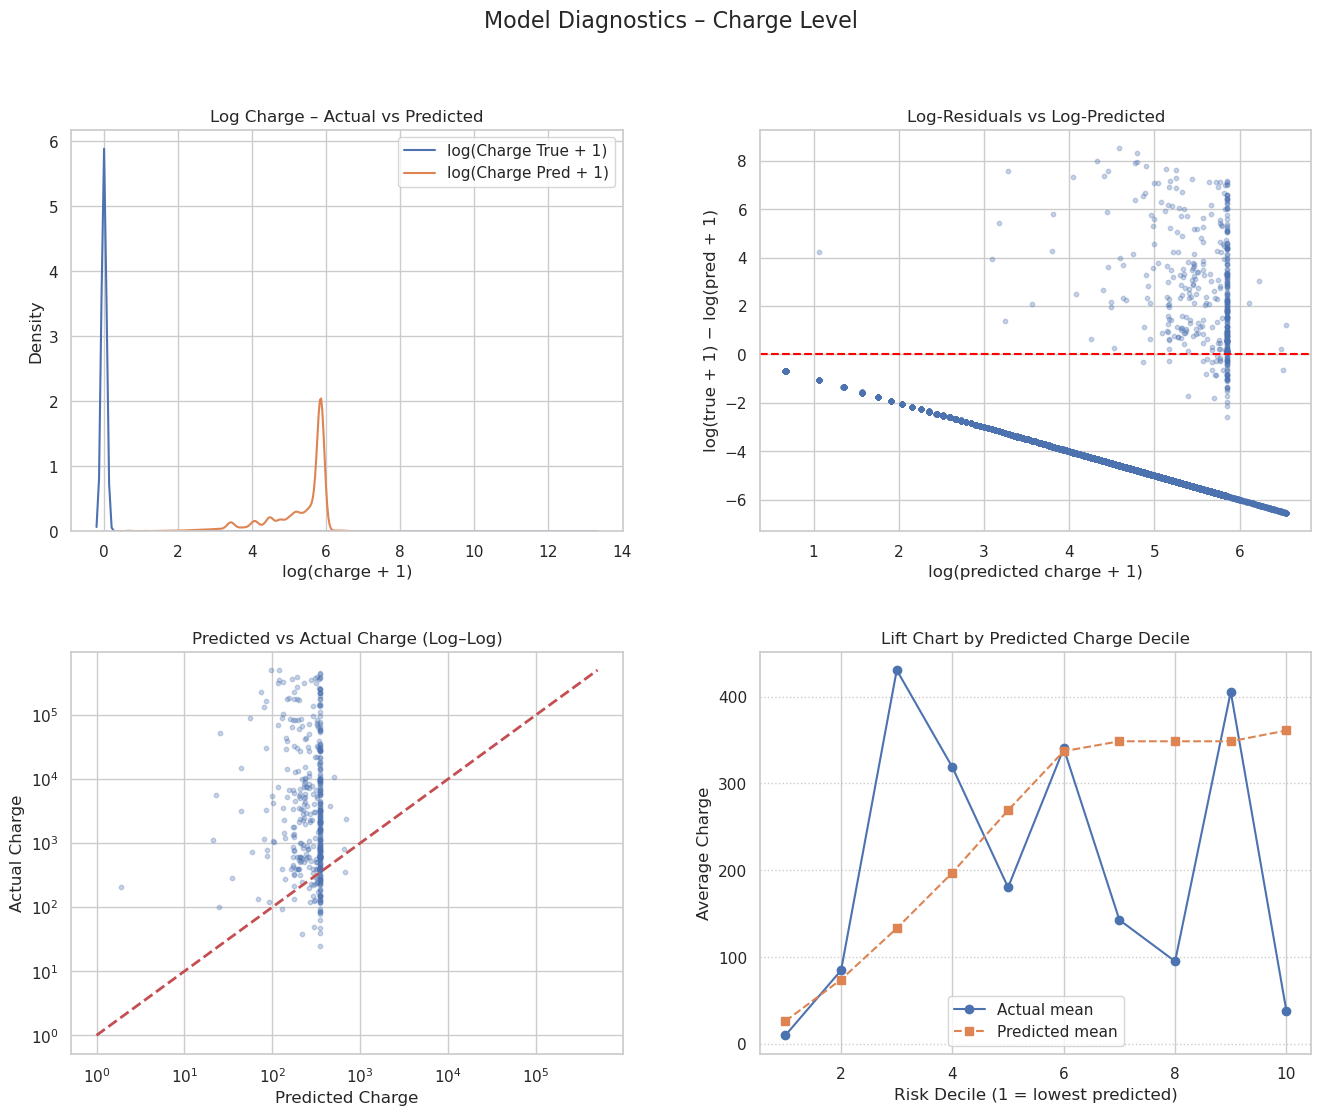

In [21]:
## CHARGE

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Model Diagnostics – Charge Level", fontsize=16)
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# (1,1) Log(actual) vs Log(pred) densities
ax = axes[0, 0]
sns.kdeplot(df_val["log_true"], label="log(Charge True + 1)", ax=ax)
sns.kdeplot(df_val["log_pred"], label="log(Charge Pred + 1)", ax=ax)
ax.set_title("Log Charge – Actual vs Predicted")
ax.set_xlabel("log(charge + 1)")
ax.legend()

# (1,2) Log-residuals vs log-predicted
ax = axes[0, 1]
ax.scatter(df_val["log_pred"], df_val["log_resid"], alpha=0.3, s=10)
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Log-Residuals vs Log-Predicted")
ax.set_xlabel("log(predicted charge + 1)")
ax.set_ylabel("log(true + 1) − log(pred + 1)")

# (2,1) Predicted vs Actual charge (log–log)
ax = axes[1, 0]
mask_pos = df_val["charge_true"] > 0
ax.scatter(
    df_val.loc[mask_pos, "charge_pred"],
    df_val.loc[mask_pos, "charge_true"],
    alpha=0.3,
    s=10,
)
max_val = max(df_val["charge_pred"].max(), df_val["charge_true"].max())
ax.plot([1, max_val], [1, max_val], "r--", linewidth=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Predicted vs Actual Charge (Log–Log)")
ax.set_xlabel("Predicted Charge")
ax.set_ylabel("Actual Charge")

# (2,2) Decile lift chart
ax = axes[1, 1]
# Rank by predicted charge and split into 10 groups
df_val_sorted = df_val.sort_values("charge_pred").reset_index(drop=True)
df_val_sorted["decile"] = pd.qcut(
    df_val_sorted.index,
    q=10,
    labels=False,
)

decile_stats = df_val_sorted.groupby("decile")[["charge_true", "charge_pred"]].mean()
x = np.arange(1, 11)

ax.plot(x, decile_stats["charge_true"], marker="o", label="Actual mean")
ax.plot(x, decile_stats["charge_pred"], marker="s", linestyle="--", label="Predicted mean")
ax.set_title("Lift Chart by Predicted Charge Decile")
ax.set_xlabel("Risk Decile (1 = lowest predicted)")
ax.set_ylabel("Average Charge")
ax.legend()
ax.grid(axis="y", linestyle=":")

plt.show()

- Log Charge – Actual vs Predicted: The predicted log-charge distribution is far higher and narrower than the true distribution, showing that the model systematically overestimates charge and fails to represent real variability.
- Log-Residuals vs Log-Predicted: Residuals show a strong downward trend, indicating that the model increasingly overpredicts charge as predicted values rise, revealing severe miscalibration.
- Predicted vs Actual Charge (Log–Log): Predicted charges cluster tightly around a narrow band while actual charges span several orders of magnitude, confirming that the model severely underfits the true charge distribution.
- Lift Chart by Predicted Charge Decile: The lift chart shows that predicted charges increase smoothly with deciles while actual charges fluctuate wildly, demonstrating that the model captures ranking only weakly and lacks discrimination power.

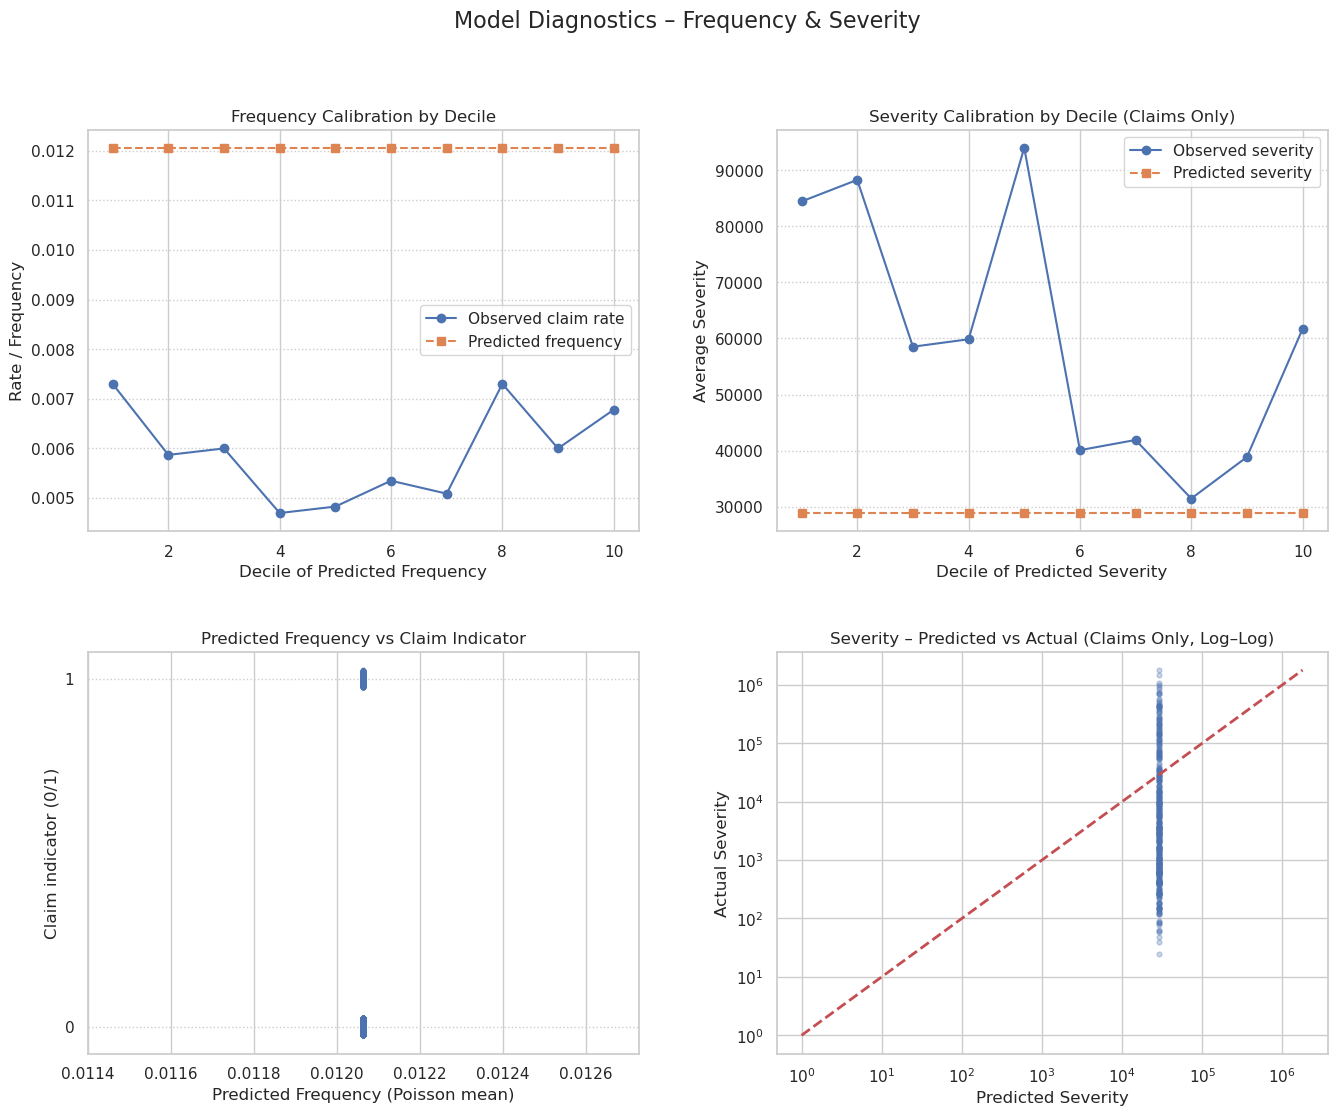

In [22]:
## FREQUENCY & SEVERITY

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Model Diagnostics – Frequency & Severity", fontsize=16)
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# (1,1) Frequency calibration by decile
ax = axes2[0, 0]

df_freq = df_val.copy()
df_freq_sorted = df_freq.sort_values("freq_pred").reset_index(drop=True)
df_freq_sorted["decile"] = pd.qcut(
    df_freq_sorted.index,
    q=10,
    labels=False,
)

# Observed claim probability per decile
freq_stats = df_freq_sorted.groupby("decile").agg(
    obs_rate=("has_claim", "mean"),
    pred_rate=("freq_pred", "mean"),
)

x = np.arange(1, 11)
ax.plot(x, freq_stats["obs_rate"], marker="o", label="Observed claim rate")
ax.plot(x, freq_stats["pred_rate"], marker="s", linestyle="--", label="Predicted frequency")
ax.set_title("Frequency Calibration by Decile")
ax.set_xlabel("Decile of Predicted Frequency")
ax.set_ylabel("Rate / Frequency")
ax.legend()
ax.grid(axis="y", linestyle=":")

# (1,2) Severity calibration by decile (claims only)
ax = axes2[0, 1]

df_sev = df_val[df_val["has_claim"] == 1].copy()
# Guard against empty
if len(df_sev) > 0:
    df_sev_sorted = df_sev.sort_values("sev_pred").reset_index(drop=True)
    df_sev_sorted["decile"] = pd.qcut(
        df_sev_sorted.index,
        q=10,
        labels=False,
    )

    sev_stats = df_sev_sorted.groupby("decile").agg(
        obs_sev=("sev_true", "mean"),
        pred_sev=("sev_pred", "mean"),
    )

    x = np.arange(1, 11)
    ax.plot(x, sev_stats["obs_sev"], marker="o", label="Observed severity")
    ax.plot(x, sev_stats["pred_sev"], marker="s", linestyle="--", label="Predicted severity")
    ax.set_title("Severity Calibration by Decile (Claims Only)")
    ax.set_xlabel("Decile of Predicted Severity")
    ax.set_ylabel("Average Severity")
    ax.legend()
    ax.grid(axis="y", linestyle=":")
else:
    ax.text(0.5, 0.5, "No positive claims in validation set",
            ha="center", va="center")
    ax.set_axis_off()

# (2,1) Predicted frequency vs observed claim indicator
ax = axes2[1, 0]

jitter = (np.random.rand(len(df_val)) - 0.5) * 0.05
ax.scatter(
    df_val["freq_pred"],
    df_val["has_claim"] + jitter,
    alpha=0.2,
    s=10,
)
ax.set_title("Predicted Frequency vs Claim Indicator")
ax.set_xlabel("Predicted Frequency (Poisson mean)")
ax.set_ylabel("Claim indicator (0/1)")
ax.set_yticks([0, 1])
ax.grid(axis="y", linestyle=":")

# (2,2) Severity scatter (claims only, log–log)
ax = axes2[1, 1]
if len(df_sev) > 0:
    ax.scatter(
        df_sev["sev_pred"],
        df_sev["sev_true"],
        alpha=0.3,
        s=12,
    )
    max_sev_val = max(df_sev["sev_pred"].max(), df_sev["sev_true"].max())
    ax.plot([1, max_sev_val], [1, max_sev_val], "r--", linewidth=2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("Severity – Predicted vs Actual (Claims Only, Log–Log)")
    ax.set_xlabel("Predicted Severity")
    ax.set_ylabel("Actual Severity")
else:
    ax.text(0.5, 0.5, "No positive claims in validation set",
            ha="center", va="center")
    ax.set_axis_off()

plt.show()

- Frequency Calibration by Decile: The predicted frequencies are nearly constant across all deciles, indicating the Poisson GLM is not capturing meaningful variation in claim likelihood.

- Severity Calibration by Decile: The severity model severely underestimates actual severities and shows almost no differentiation across deciles, revealing strong underfitting of the Tweedie GLM.

- Predicted Frequency vs Claim Indicator: Predicted frequencies collapse to a single narrow band, confirming that the model outputs nearly identical values regardless of claim outcome.

- Severity – Predicted vs Actual (Log–Log): Predicted severities form a vertical line far below the identity line, showing that the model predicts a constant severity and fails to capture the heavy-tailed actual distribution.